# FINAL EXAM MODEL DEPLOYMENT
### Nama : Anthony Tio Sebastian Budiarto
### NIM : 2802412540

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("data_C.csv")

print("Jumlah baris dan kolom:", df.shape)
display(df.head())
display(df.tail())

Jumlah baris dan kolom: (25000, 29)


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,6,8,32,3,"Personal Loan, Student Loan, and Mortgage Loan",23,9,10.3,11.0,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.917665,Standard
1,1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,9,10,1663,2,"Personal Loan, and Student Loan",58,14,15.53,6.0,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813453877,Low_spent_Medium_value_payments,309.130981,Poor
2,2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,1,6,2,1,Auto Loan,25,4,5.04,1.0,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574716999517,High_spent_Small_value_payments,920.817597,Standard
3,3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,NaN,3,7,5,0,NaN,30,15,24.73,6.0,Standard,987.07,26.786925,17 Years and 7 Months,Yes,0.000000,65.84983488267585,Low_spent_Large_value_payments,391.890332,Standard
4,4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,992.736250,4,1405,14,6,"Auto Loan, Payday Loan, Student Loan, Auto Loa...",30,19,16.44,7.0,Standard,177.98,24.001752,14 Years and 7 Months,Yes,35.562731,NaN,Low_spent_Small_value_payments,228.245999,Standard


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
24995,24995,0xd98c,CUS_0xc045,July,Sarahd,20,281-30-1712,Media_Manager,30622.73,2366.384852,4,2,11,4,"Credit-Builder Loan, Home Equity Loan, Student...",12,1,4.87,1.0,_,383.33,34.502605,NaN,No,225.844807,__10000__,Low_spent_Small_value_payments,151.188270,Good
24996,24996,0x6864,CUS_0x93a5,July,Patrick Temple-Westt,45,905-92-0207,Lawyer,16060.675,1422.375479,6,7,7,3,"Mortgage Loan, Debt Consolidation Loan, and De...",17,16,9.79,8.0,_,57.82,23.638128,17 Years and 11 Months,Yes,196.565077,173.00838188143973,Low_spent_Small_value_payments,239.779603,Standard
24997,24997,0x1f9e6,CUS_0x18ca,January,Seetharamank,4824,300-10-5653,Engineer,79716.94,6372.078333,0,4,6,1,Payday Loan,15,7,1.6300000000000008,4.0,Good,1248.42,28.066339,19 Years and 5 Months,No,57.207322,107.61437209144957,High_spent_Large_value_payments,712.386140,Standard
24998,24998,0x878f,CUS_0x376e,June,Palmerz,47,084-31-1205,Mechanic,104255.67,8571.972500,6,3,18,3,"Payday Loan, Credit-Builder Loan, and Auto Loan",12,8,2.46,6.0,Standard,992.62,42.756139,15 Years and 8 Months,No,133.991067,104.33015290773486,High_spent_Large_value_payments,858.876030,Standard
24999,24999,0x1fc32,CUS_0x867f,January,Clarken,27,834-62-2160,Musician,18525.13,NaN,10,9,34,2,"Mortgage Loan, and Debt Consolidation Loan",21,NaN,20.47,7.0,_,1632.9,27.901867,10 Years and 5 Months,Yes,18.408032,NaN,Low_spent_Small_value_payments,211.403531,Standard


### BASIC DATA INFORMATION

In [3]:
print("Informasi dataset:")
df.info()

print("\nStatistik deskriptif numerik:")
display(df.describe())

print("\nStatistik deskriptif kategorikal:")
display(df.describe(include="object"))

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22570 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21164 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  

,Unnamed: 0,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month,Monthly_Balance
count,25000.000000,21164.000000,25000.000000,25000.000000,25000.000000,25000.000000,24528.000000,25000.000000,25000.000000,24699.000000
mean,12499.500000,4189.505970,18.075360,22.238000,75.407480,20.988400,28.449976,32.277257,1465.714590,403.454486
std,7217.022701,3208.575501,122.375374,126.156225,478.786499,14.851345,197.078633,5.126823,8514.582351,215.613056
min,0.000000,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.100770,0.000000,0.088628
25%,6249.750000,1611.188333,3.000000,4.000000,8.000000,10.000000,3.000000,28.043382,30.181528,269.935928
50%,12499.500000,3071.424583,6.000000,5.000000,14.000000,18.000000,6.000000,32.309314,68.248891,335.519841
75%,18749.250000,5941.093333,7.000000,7.000000,20.000000,28.000000,9.000000,36.488060,159.990097,472.202042
max,24999.000000,15204.633333,1789.000000,1498.000000,5797.000000,67.000000,2592.000000,50.000000,82331.000000,1564.134826



Statistik deskriptif kategorikal:


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Credit_Score
count,25000,25000,25000,22570,25000,25000,25000,25000,25000,22148,23208,25000,25000,25000,22760,25000,23866,25000,25000
unique,25000,11254,8,8995,551,11061,16,12845,150,5731,235,3428,4,11257,403,3,22773,7,3
top,0x20419,CUS_0x5067,February,Langep,35,#F%$D@*&8,_______,35104.32,3,Not Specified,19,_,Standard,1319.87,17 Years and 11 Months,Yes,__10000__,Low_spent_Small_value_payments,Standard
freq,1,7,3203,14,743,1385,1765,7,3609,345,1370,518,9170,8,129,13082,1049,6377,13282


From the `info()` result, I found that the dataset contains both numerical and categorical columns. However, some columns that should be numerical, such as `Age`, `Annual_Income`, `Num_of_Loan`, and `Outstanding_Debt`, were still stored as object data type. This happened because the columns contained invalid characters or inconsistent values, so they needed to be cleaned and converted into numerical format before modelling.

### Cek Missing Value dan Nilai Unik

In [4]:
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2),
    "Data Type": df.dtypes
}).sort_values(by="Missing Values", ascending=False)

display(missing_table)

,Missing Values,Percentage (%),Data Type
Monthly_Inhand_Salary,3836,15.34,float64
Type_of_Loan,2852,11.41,object
Name,2430,9.72,object
Credit_History_Age,2240,8.96,object
Num_of_Delayed_Payment,1792,7.17,object
Amount_invested_monthly,1134,4.54,object
Num_Credit_Inquiries,472,1.89,float64
Monthly_Balance,301,1.20,float64
Payment_Behaviour,0,0.00,object
Total_EMI_per_month,0,0.00,float64


In [5]:
unique_table = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes
}).sort_values(by="Unique Values", ascending=False)

display(unique_table)

,Unique Values,Data Type
Unnamed: 0,25000,int64
ID,25000,object
Credit_Utilization_Ratio,25000,float64
Monthly_Balance,24699,float64
Amount_invested_monthly,22773,object
Annual_Income,12845,object
Outstanding_Debt,11257,object
Customer_ID,11254,object
SSN,11061,object
Total_EMI_per_month,10978,float64


Some columns had missing values, such as `Monthly_Inhand_Salary`, `Type_of_Loan`, `Credit_History_Age`, and several other financial features. Besides normal missing values, I also found invalid values like `_______`, `_`, `!@9#%8`, `NM`, and `__10000__`. I changed these invalid values into `NaN` so they could be handled properly during preprocessing.

### Cek Duplikasi Data

In [6]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


### Target Distribution

,Count,Percentage (%)
Credit_Score,,
Standard,13282,53.13
Poor,7268,29.07
Good,4450,17.80


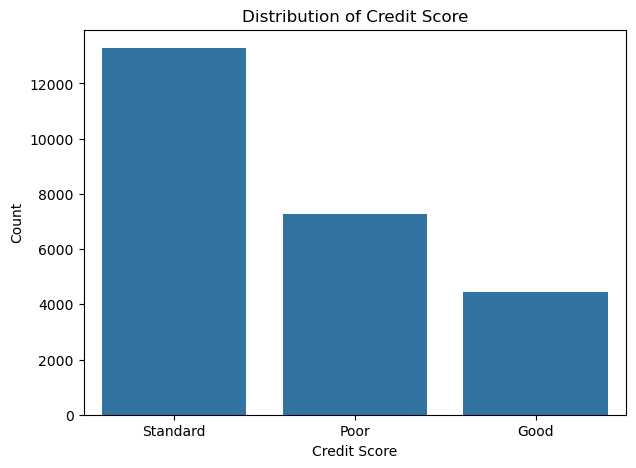

In [7]:
target_counts = df["Credit_Score"].value_counts()
target_percentage = df["Credit_Score"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_percentage.round(2)
})

display(target_summary)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Credit_Score", order=target_counts.index)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.show()

The largest class in the target variable is `Standard`, while the smallest class is `Good`. This shows that the dataset is slightly to moderately imbalanced. Because of this, I should not evaluate the model using accuracy only. I also need to use precision, recall, F1-score, and confusion matrix to check how well the model performs for each class.

### Cek Anomali / Invalid Value

In [8]:
invalid_values = ["_______", "_", "!@9#%8", "#F%$D@*&8", "NM", "__10000__"]

for col in df.columns:
    count_invalid = df[col].isin(invalid_values).sum()
    if count_invalid > 0:
        print(f"{col}: {count_invalid} invalid values")

SSN: 1385 invalid values
Occupation: 1765 invalid values
Changed_Credit_Limit: 518 invalid values
Credit_Mix: 4926 invalid values
Payment_of_Min_Amount: 2947 invalid values
Amount_invested_monthly: 1049 invalid values
Payment_Behaviour: 1951 invalid values


### Visualization

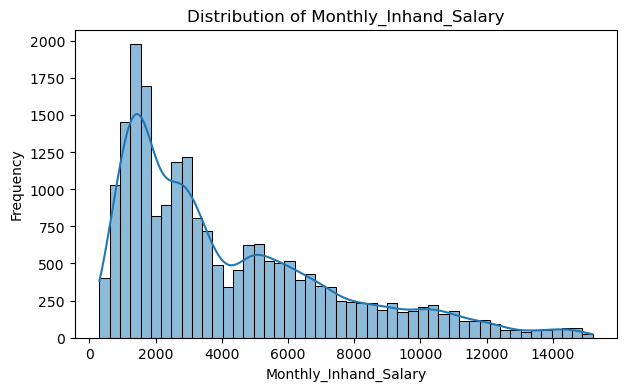

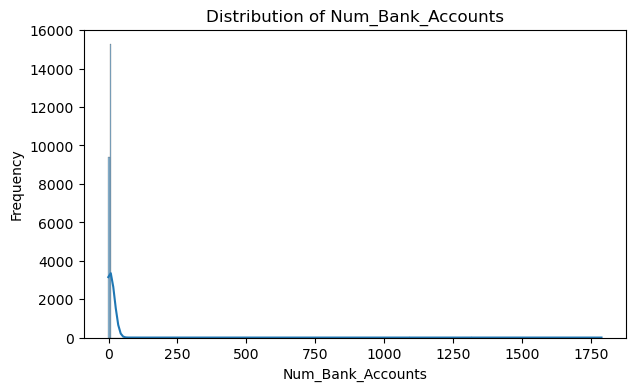

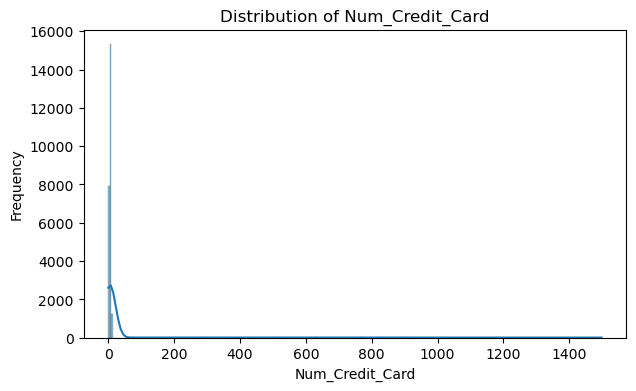

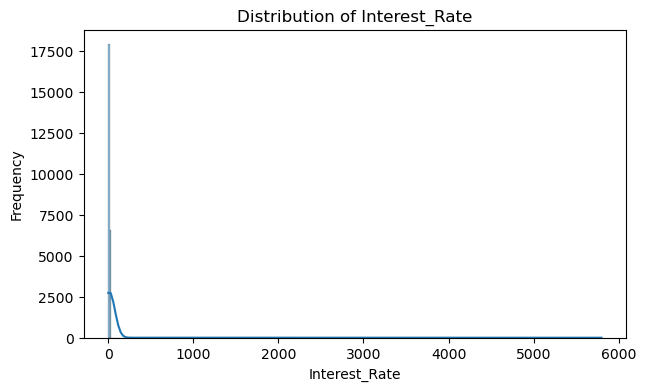

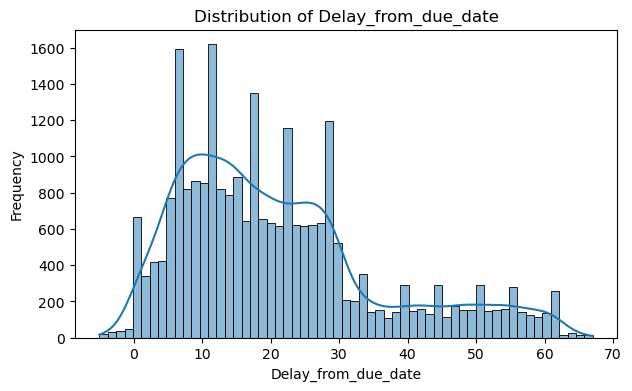

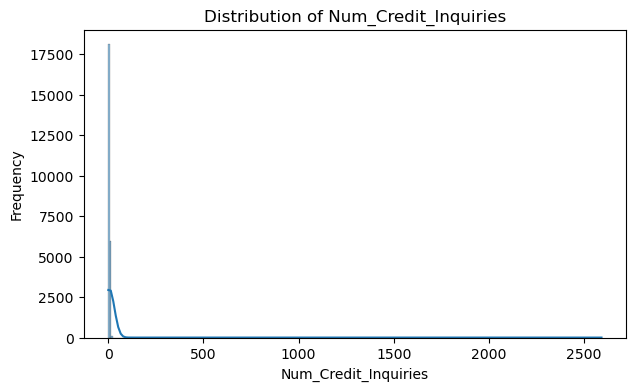

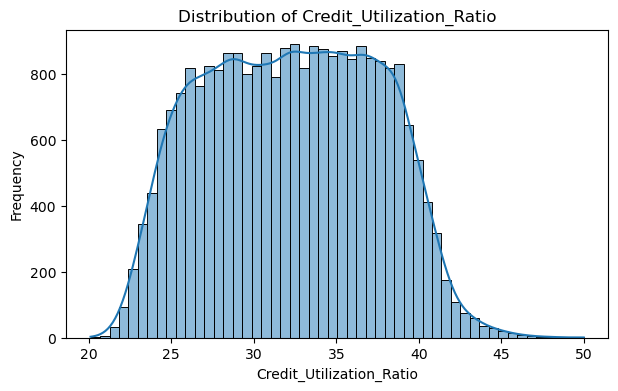

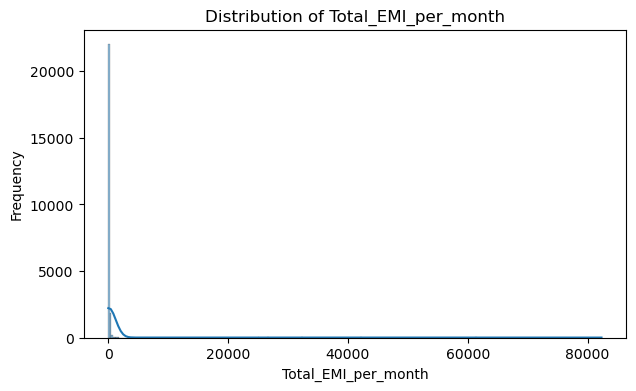

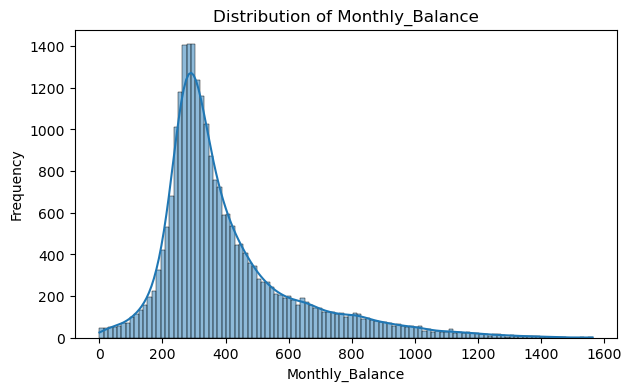

In [9]:
# Numerical feature distributions
numerical_preview = [
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Delay_from_due_date",
    "Num_Credit_Inquiries",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Monthly_Balance"
]

for col in numerical_preview:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

Visualisasi distribusi numerik digunakan untuk melihat pola penyebaran data, skewness, serta kemungkinan adanya outlier. Beberapa fitur seperti Interest_Rate, Delay_from_due_date, Outstanding_Debt, dan Monthly_Balance berpotensi memiliki hubungan kuat dengan risiko kredit karena merepresentasikan kondisi dan perilaku finansial nasabah.

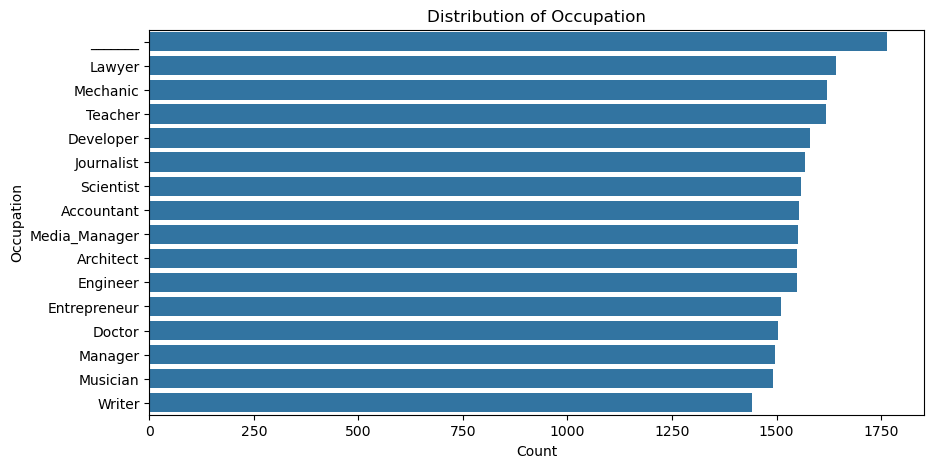

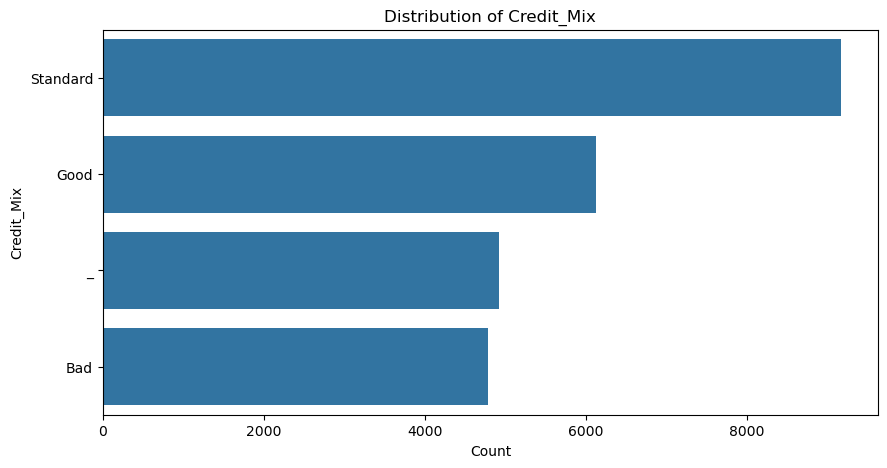

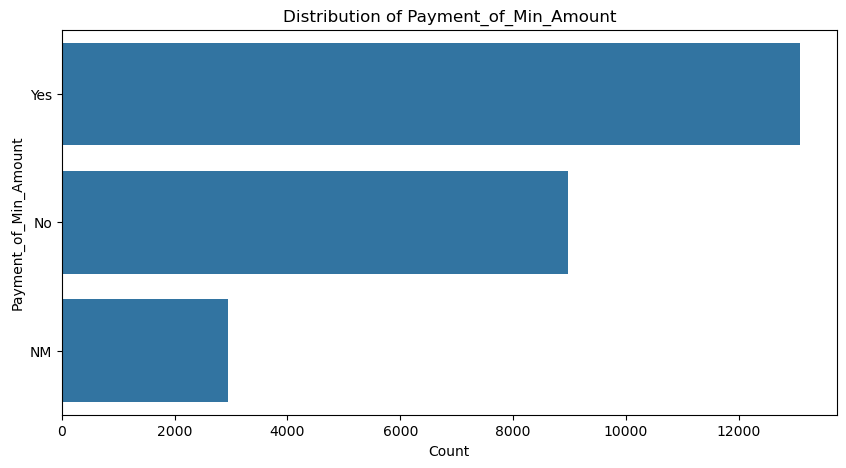

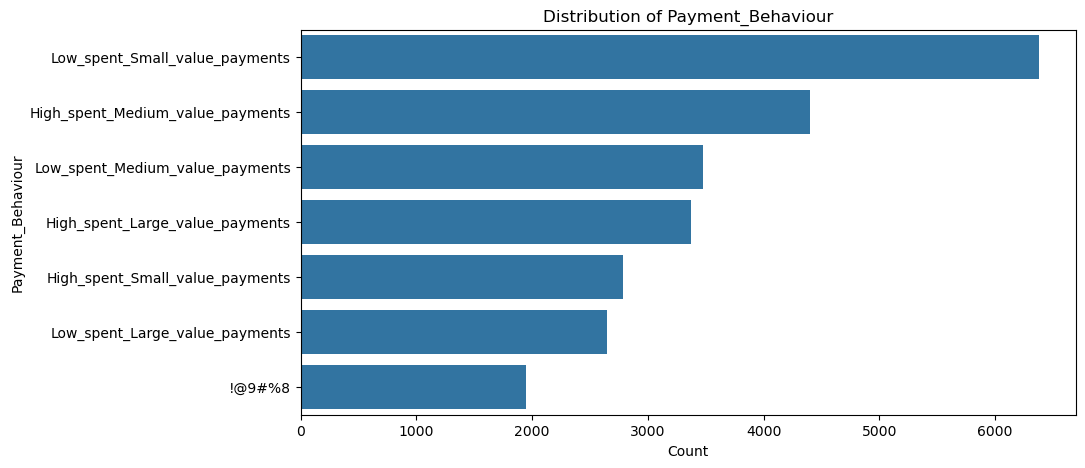

In [10]:
# Categorical Feature Distribution
categorical_preview = [
    "Occupation",
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour"
]

for col in categorical_preview:
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.title(f"Distribution of {col}")
        plt.xlabel("Count")
        plt.ylabel(col)
        plt.show()

I used categorical feature visualization to see the distribution of each category. From this step, I found some invalid categories such as `_______`, `_`, `NM`, and `!@9#%8`. Since these values do not have a clear meaning, I treated them as missing values.

In [11]:
df_clean = df.copy()

### Drop Irrelevant Columns

In [12]:
drop_columns = [
    "Unnamed: 0",
    "ID",
    "Customer_ID",
    "Name",
    "SSN"
]

df_clean = df_clean.drop(columns=[col for col in drop_columns if col in df_clean.columns])

print("Shape setelah drop kolom tidak relevan:", df_clean.shape)
display(df_clean.head())

Shape setelah drop kolom tidak relevan: (25000, 24)


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,August,35,Journalist,20364.57,1626.047500,6,8,32,3,"Personal Loan, Student Loan, and Mortgage Loan",23,9,10.3,11.0,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.917665,Standard
1,August,46,Teacher,9786.86,951.571667,9,10,1663,2,"Personal Loan, and Student Loan",58,14,15.53,6.0,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813453877,Low_spent_Medium_value_payments,309.130981,Poor
2,June,19,_______,146880.84,12372.070000,1,6,2,1,Auto Loan,25,4,5.04,1.0,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574716999517,High_spent_Small_value_payments,920.817597,Standard
3,April,39,Developer,23200.82,NaN,3,7,5,0,NaN,30,15,24.73,6.0,Standard,987.07,26.786925,17 Years and 7 Months,Yes,0.000000,65.84983488267585,Low_spent_Large_value_payments,391.890332,Standard
4,April,20,Architect,11336.835,992.736250,4,1405,14,6,"Auto Loan, Payday Loan, Student Loan, Auto Loa...",30,19,16.44,7.0,Standard,177.98,24.001752,14 Years and 7 Months,Yes,35.562731,NaN,Low_spent_Small_value_payments,228.245999,Standard


### Change invalid value to NaN

In [13]:
invalid_values = ["_______", "_", "!@9#%8", "#F%$D@*&8", "NM", "__10000__"]

df_clean = df_clean.replace(invalid_values, np.nan)

missing_after_invalid = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage (%)": (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
}).sort_values(by="Missing Values", ascending=False)

display(missing_after_invalid)

,Missing Values,Percentage (%)
Credit_Mix,4926,19.70
Monthly_Inhand_Salary,3836,15.34
Payment_of_Min_Amount,2947,11.79
Type_of_Loan,2852,11.41
Credit_History_Age,2240,8.96
Amount_invested_monthly,2183,8.73
Payment_Behaviour,1951,7.80
Num_of_Delayed_Payment,1792,7.17
Occupation,1765,7.06
Changed_Credit_Limit,518,2.07


### Clean numeric columns stored as object

In [14]:
def clean_numeric_column(series):
    """
    Membersihkan kolom numerik yang masih berbentuk object/string.
    Contoh nilai bermasalah:
    '28_' -> 28
    '_10000_' -> 10000
    string invalid -> NaN
    """
    return pd.to_numeric(
        series.astype(str)
              .str.replace("_", "", regex=False)
              .str.strip(),
        errors="coerce"
    )

numeric_object_cols = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly"
]

for col in numeric_object_cols:
    if col in df_clean.columns:
        df_clean[col] = clean_numeric_column(df_clean[col])

print("Tipe data setelah konversi numerik:")
display(df_clean[numeric_object_cols].dtypes)

Tipe data setelah konversi numerik:


Age                          int64
Annual_Income              float64
Num_of_Loan                  int64
Num_of_Delayed_Payment     float64
Changed_Credit_Limit       float64
Outstanding_Debt           float64
Amount_invested_monthly    float64
dtype: object

### Convert Month to Numeric

In [15]:
month_mapping = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12
}

df_clean["Month"] = df_clean["Month"].map(month_mapping)

display(df_clean[["Month"]].head())

,Month
0,8
1,8
2,6
3,4
4,4


### Convert Credit History Age to Months

In [16]:
def credit_history_to_months(value):
    
    if pd.isna(value):
        return np.nan
    
    value = str(value)
    
    years = re.search(r"(\d+)\s*Years?", value)
    months = re.search(r"(\d+)\s*Months?", value)
    
    total_months = 0
    
    if years:
        total_months += int(years.group(1)) * 12
    
    if months:
        total_months += int(months.group(1))
    
    return total_months

df_clean["Credit_History_Age_Months"] = df_clean["Credit_History_Age"].apply(credit_history_to_months)

df_clean = df_clean.drop(columns=["Credit_History_Age"])

display(df_clean[["Credit_History_Age_Months"]].head())

,Credit_History_Age_Months
0,116.0
1,NaN
2,291.0
3,211.0
4,175.0


### Feature Engineering Type of Load

In [17]:
loan_types = [
    "Auto Loan",
    "Credit-Builder Loan",
    "Debt Consolidation Loan",
    "Home Equity Loan",
    "Mortgage Loan",
    "Not Specified",
    "Payday Loan",
    "Personal Loan",
    "Student Loan"
]

# Simpan versi asli sebelum drop
type_of_loan_raw = df["Type_of_Loan"].fillna("")

for loan in loan_types:
    new_col = "Loan_" + loan.replace(" ", "_").replace("-", "_")
    df_clean[new_col] = type_of_loan_raw.str.contains(
        loan, 
        case=False, 
        regex=False
    ).astype(int)

def count_loan_types(value):
    if pd.isna(value) or value == "":
        return 0
    
    value = str(value).replace("and ", "")
    loans = [loan.strip() for loan in value.split(",") if loan.strip() != ""]
    return len(loans)

df_clean["Loan_Type_Count"] = type_of_loan_raw.apply(count_loan_types)

df_clean = df_clean.drop(columns=["Type_of_Loan"])

loan_feature_cols = [col for col in df_clean.columns if col.startswith("Loan_")]
display(df_clean[loan_feature_cols].head())

,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Debt_Consolidation_Loan,Loan_Home_Equity_Loan,Loan_Mortgage_Loan,Loan_Not_Specified,Loan_Payday_Loan,Loan_Personal_Loan,Loan_Student_Loan,Loan_Type_Count
0,0,0,0,0,1,0,0,1,1,3
1,0,0,0,0,0,0,0,1,1,2
2,1,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,1,1,1,6


The `Type_of_Loan` column had many unique combinations because one customer can have more than one loan type. Instead of applying one-hot encoding directly to all combinations, I separated it into several loan indicator features to make the data easier for the model to process.

### handle Impossible / Illogical Values

In [18]:
value_bounds = {
    "Age": (18, 100),
    "Annual_Income": (0, 500000),
    "Monthly_Inhand_Salary": (0, 50000),
    "Num_Bank_Accounts": (0, 20),
    "Num_Credit_Card": (0, 20),
    "Interest_Rate": (0, 50),
    "Num_of_Loan": (0, 20),
    "Delay_from_due_date": (0, 90),
    "Num_of_Delayed_Payment": (0, 60),
    "Changed_Credit_Limit": (-50, 50),
    "Num_Credit_Inquiries": (0, 50),
    "Outstanding_Debt": (0, 100000),
    "Credit_Utilization_Ratio": (0, 100),
    "Total_EMI_per_month": (0, 50000),
    "Amount_invested_monthly": (0, 50000),
    "Monthly_Balance": (0, 50000),
    "Credit_History_Age_Months": (0, 600)
}

invalid_summary = []

for col, (lower, upper) in value_bounds.items():
    if col in df_clean.columns:
        invalid_count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
        
        df_clean.loc[
            (df_clean[col] < lower) | (df_clean[col] > upper),
            col
        ] = np.nan
        
        invalid_summary.append({
            "Column": col,
            "Invalid Values Converted to NaN": invalid_count
        })

invalid_summary = pd.DataFrame(invalid_summary)
display(invalid_summary.sort_values(by="Invalid Values Converted to NaN", ascending=False))

,Column,Invalid Values Converted to NaN
0,Age,2172
6,Num_of_Loan,1107
4,Num_Credit_Card,566
5,Interest_Rate,534
10,Num_Credit_Inquiries,412
3,Num_Bank_Accounts,361
8,Num_of_Delayed_Payment,326
13,Total_EMI_per_month,325
1,Annual_Income,222
7,Delay_from_due_date,129


Some numerical columns had values that did not make sense, such as unrealistic age, extreme numbers of bank accounts or credit cards, negative loan values, and unusual interest rates. I changed these values into missing values instead of deleting the rows, so the dataset size could still be maintained and handled later through imputation.

### Missing Value after Cleaning

In [19]:
missing_after_cleaning = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage (%)": (df_clean.isnull().sum() / len(df_clean) * 100).round(2),
    "Data Type": df_clean.dtypes
}).sort_values(by="Missing Values", ascending=False)

display(missing_after_cleaning)

,Missing Values,Percentage (%),Data Type
Credit_Mix,4926,19.70,object
Monthly_Inhand_Salary,3836,15.34,float64
Payment_of_Min_Amount,2947,11.79,object
Credit_History_Age_Months,2240,8.96,float64
Amount_invested_monthly,2183,8.73,float64
Age,2172,8.69,float64
Num_of_Delayed_Payment,2118,8.47,float64
Payment_Behaviour,1951,7.80,object
Occupation,1765,7.06,object
Num_of_Loan,1107,4.43,float64


### Split Feature and target

In [21]:
X = df_clean.drop(columns=["Credit_Score"])
y = df_clean["Credit_Score"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

display(y.value_counts())

Shape X: (25000, 32)
Shape y: (25000,)


Credit_Score
Standard    13282
Poor         7268
Good         4450
Name: count, dtype: int64

### Encode

In [22]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print("Label Mapping:")
print(label_mapping)

Label Mapping:
{'Good': np.int64(0), 'Poor': np.int64(1), 'Standard': np.int64(2)}


### Train-test SPlit

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (20000, 32)
X_test : (5000, 32)
y_train: (20000,)
y_test : (5000,)


In [24]:
# Cek distribusi target setelah split
print("Distribusi target train:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))

print("\nDistribusi target test:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))

Distribusi target train:
2    0.531
1    0.291
0    0.178
Name: proportion, dtype: float64

Distribusi target test:
2    0.531
1    0.291
0    0.178
Name: proportion, dtype: float64


### Indentify Numerical and categorical Columns

In [26]:
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Jumlah kolom numerik:", len(numerical_cols))
print(numerical_cols)

print("\nJumlah kolom kategorikal:", len(categorical_cols))
print(categorical_cols)

Jumlah kolom numerik: 28
['Month', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months', 'Loan_Auto_Loan', 'Loan_Credit_Builder_Loan', 'Loan_Debt_Consolidation_Loan', 'Loan_Home_Equity_Loan', 'Loan_Mortgage_Loan', 'Loan_Not_Specified', 'Loan_Payday_Loan', 'Loan_Personal_Loan', 'Loan_Student_Loan', 'Loan_Type_Count']

Jumlah kolom kategorikal: 4
['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


### Preprocessing Pipeline

In [27]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### Apply

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape X_train_processed:", X_train_processed.shape)
print("Shape X_test_processed :", X_test_processed.shape)

Shape X_train_processed: (20000, 54)
Shape X_test_processed : (5000, 54)


The preprocessor was fitted only on the training data, then the same preprocessor was used to transform both the training and testing data. I did this to avoid data leakage, because the testing data should not influence the training process in any way.

After the preprocessing step, the data is already in a proper format for machine learning training. The next step is to train several models, such as Logistic Regression, Random Forest, XGBoost, SVM, or other suitable models, and compare their performance.

In [30]:
print(np.isnan(X_train_processed.toarray()).sum() if hasattr(X_train_processed, "toarray") else np.isnan(X_train_processed).sum())

print(np.isnan(X_test_processed.toarray()).sum() if hasattr(X_test_processed, "toarray") else np.isnan(X_test_processed).sum())

0
0


In [31]:
import joblib

df_clean.to_csv("cleaned_credit_score_data.csv", index=False)

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Cleaned data saved as cleaned_credit_score_data.csv")
print("Preprocessor saved as preprocessor.pkl")
print("Label encoder saved as label_encoder.pkl")

Cleaned data saved as cleaned_credit_score_data.csv
Preprocessor saved as preprocessor.pkl
Label encoder saved as label_encoder.pkl


## EDA and Preprocessing Conclusion

From the EDA, I found that the dataset has 25,000 rows and 29 columns. The target column is Credit_Score, which has three classes: Good, Poor, and Standard. The data is slightly imbalanced because Standard has the most records, while Good has the least. Because of this, I will not only use accuracy for evaluation, but also precision, recall, F1-score, and confusion matrix.

I also found some data quality issues. Some numerical columns were still stored as object data type because they contained invalid characters or inconsistent values. There were also unclear categorical values such as _______, _, !@9#%8, and NM. I treated these values as missing values so they could be handled properly during preprocessing.

Several identity columns, such as ID, Customer_ID, Name, and SSN, were removed because they are not useful for predicting credit score. These columns only identify each customer and may cause the model to memorize the data instead of learning the real financial patterns.

For preprocessing, I converted numerical columns into the correct numeric format, changed Month into a number, converted Credit_History_Age into total months, and transformed Type_of_Loan into several loan indicator features. I also changed illogical numerical values into missing values before applying imputation.

After cleaning the data, I split it into training and testing sets using stratified sampling to keep the class distribution balanced. Numerical features were handled using median imputation and standard scaling, while categorical features were handled using most frequent imputation and one-hot encoding. After these steps, the data is ready for machine learning training.

## Modelling + Evaluation

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

In [33]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [34]:
results = []

trained_models = {}

for model_name, model in models.items():
    print("=" * 70)
    print(f"Training Model: {model_name}")
    print("=" * 70)
    
    # Train model
    model.fit(X_train_processed, y_train)
    
    # Predict test data
    y_pred = model.predict(X_test_processed)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")
    
    # Save result
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision_Macro": precision,
        "Recall_Macro": recall,
        "F1_Macro": f1
    })
    
    trained_models[model_name] = model
    
    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Precision Macro: {precision:.4f}")
    print(f"Recall Macro   : {recall:.4f}")
    print(f"F1 Macro       : {f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Training Model: Logistic Regression
Accuracy       : 0.6530
Precision Macro: 0.6335
Recall Macro   : 0.6108
F1 Macro       : 0.6191

Classification Report:
              precision    recall  f1-score   support

        Good       0.56      0.54      0.55       890
        Poor       0.67      0.54      0.60      1454
    Standard       0.67      0.75      0.71      2656

    accuracy                           0.65      5000
   macro avg       0.63      0.61      0.62      5000
weighted avg       0.65      0.65      0.65      5000

Training Model: Random Forest
Accuracy       : 0.7388
Precision Macro: 0.7197
Recall Macro   : 0.7147
F1 Macro       : 0.7170

Classification Report:
              precision    recall  f1-score   support

        Good       0.64      0.65      0.64       890
        Poor       0.76      0.71      0.73      1454
    Standard       0.76      0.78      0.77      2656

    accuracy                           0.74      5000
   macro avg       0.72      0.71      0.

### Comparison

In [35]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1_Macro", ascending=False)

display(results_df)

,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
1,Random Forest,0.7388,0.719728,0.714739,0.716981
2,Gradient Boosting,0.6978,0.678774,0.671144,0.673856
0,Logistic Regression,0.6530,0.633522,0.610805,0.619115


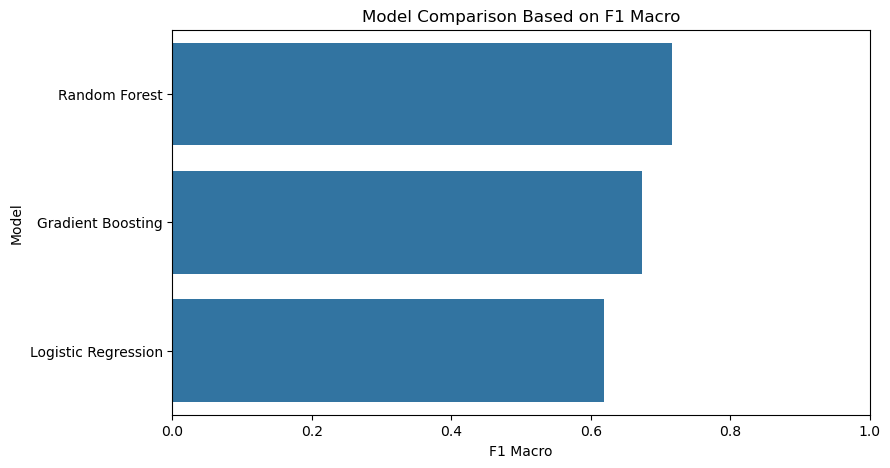

In [36]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="F1_Macro", y="Model")
plt.title("Model Comparison Based on F1 Macro")
plt.xlabel("F1 Macro")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

### Best Model

In [37]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
display(results_df.iloc[[0]])

Best Model: Random Forest


,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
1,Random Forest,0.7388,0.719728,0.714739,0.716981


### Confusion Matrix

<Figure size 700x600 with 0 Axes>

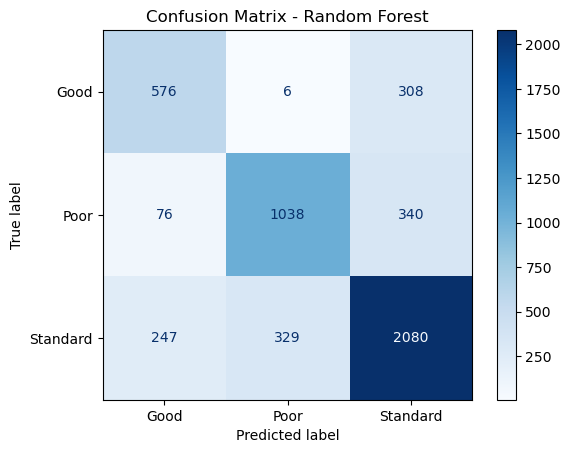

In [38]:
y_pred_best = best_model.predict(X_test_processed)

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(7, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [39]:
print(f"Classification Report for Best Model: {best_model_name}")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoder.classes_
))

Classification Report for Best Model: Random Forest
              precision    recall  f1-score   support

        Good       0.64      0.65      0.64       890
        Poor       0.76      0.71      0.73      1454
    Standard       0.76      0.78      0.77      2656

    accuracy                           0.74      5000
   macro avg       0.72      0.71      0.72      5000
weighted avg       0.74      0.74      0.74      5000



### Save best Model

In [40]:
joblib.dump(best_model, "best_model.pkl")

print(f"Best model saved as best_model.pkl")
print(f"Best model name: {best_model_name}")

Best model saved as best_model.pkl
Best model name: Random Forest


### Save Model Comparison result

In [42]:
results_df.to_csv("model_comparison.csv", index=False)

print("Model comparison result saved as model_comparison.csv")

Model comparison result saved as model_comparison.csv


## Modelling Conclusion

In this modelling step, I trained and compared several machine learning models, including Logistic Regression, Random Forest, and Gradient Boosting. Each model was trained using the same preprocessed training data and evaluated using the same testing data.

Based on the comparison result, the best model was selected using F1 Macro as the main evaluation metric. I used F1 Macro because the target classes are not fully balanced, so it is important to evaluate the model performance across all classes, not only based on the majority class.

The best model was then evaluated further using a classification report and confusion matrix. From these results, I can see how well the model predicts each credit score class and where the model still makes mistakes. Finally, the best model was saved as `best_model.pkl` so it can be used later for inference and deployment.